# Exercise 1: Classification with US Airline Sentiment Tweets

The objective of this exercise is to build a multi-class sentiment classification model using the US Airline Sentiment dataset.

Each tweet is classified into one of the following sentiment categories:

- Negative
- Neutral
- Positive

The workflow includes:

1. Data loading and exploration
2. Text preprocessing
3. Feature extraction using TF-IDF
4. Artificial Neural Network construction
5. Model training with Early Stopping
6. Performance evaluation using multiple classification metrics

## 1. Import Required Libraries

In this section, the required Python libraries are imported.

- Pandas and NumPy are used for data manipulation.
- Matplotlib is used for visualizations.
- Scikit-learn is used for preprocessing, data splitting, TF-IDF vectorization and evaluation.
- PyTorch is used to build and train the Artificial Neural Network.

### Reproducibility

A fixed random seed is used to make the experiments reproducible.

This helps ensure that differences between the initial and revised models are not simply caused by different random neural network initializations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# Reproducibility
SEED = 42

np.random.seed(SEED)
_ = torch.manual_seed(SEED)

## 2. Load the Dataset

The dataset is loaded from the provided CSV file.

An initial inspection is performed to understand:

- the first rows of the dataset
- the dataset dimensions
- the available columns
- the variable types
- the presence of missing values

In [2]:
df = pd.read_csv("Tweets.csv")

display(df.head())

print("Dataset shape:", df.shape)

df.info()

print("\nMissing values:")
print(df.isnull().sum())

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


Dataset shape: (14640, 15)
<class 'pandas.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  str    
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   str    
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  str    
 6   airline_sentiment_gold        40 non-null     str    
 7   name                          14640 non-null  str    
 8   negativereason_gold           32 non-null     str    
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  str    
 11  tweet_coord                   1019 non-null   str    
 12  tweet_created                 14640 non-null

## 3. Select Relevant Columns

For the initial classification model, only the tweet text and the corresponding sentiment label are used.

The selected columns are:

- `text`: the content of the tweet
- `airline_sentiment`: the target class

Using only the tweet text provides a simple baseline model. Additional features such as the airline name may be considered in future experiments.

In [3]:
df = df[["text", "airline_sentiment"]].copy()

display(df.head())

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


## 4. Check for Missing Values

Before preprocessing the text, the selected columns are checked for missing values.

Missing observations may cause problems during text preprocessing or model training and should therefore be handled before continuing.

In [4]:
print(df.isnull().sum())
df = df.dropna()

text                 0
airline_sentiment    0
dtype: int64


## 5. Exploratory Data Analysis

The distribution of the sentiment classes is examined.

This is particularly important because class imbalance can affect the performance of a classification model. A model may achieve relatively high accuracy by favouring the most frequent class.

In [5]:
class_counts = df["airline_sentiment"].value_counts()

print(class_counts)

print("\nClass percentages:")
print(
    df["airline_sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Class percentages:
airline_sentiment
negative    62.69
neutral     21.17
positive    16.14
Name: proportion, dtype: float64


### 5.1 Sentiment Class Distribution

The class distribution is visualized using a bar chart.

This visualization provides a clear overview of whether the three sentiment categories are equally represented in the dataset.

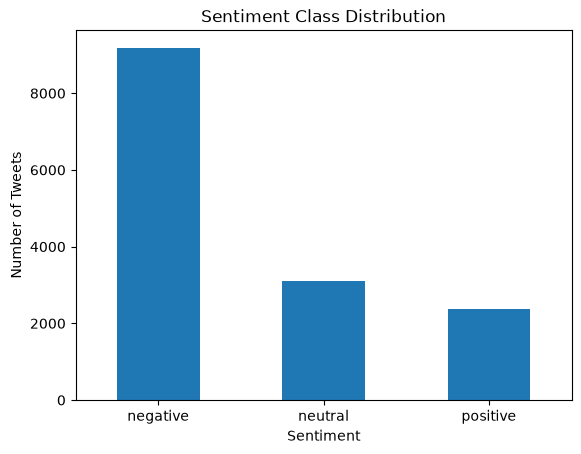

In [6]:
df["airline_sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)

plt.show()

## 6. Text Preprocessing

Raw tweets may contain elements that do not directly contribute to sentiment classification, such as:

- URLs
- user mentions
- hashtags
- punctuation
- unnecessary whitespace

The text is converted to lowercase and cleaned before feature extraction.

The preprocessing is implemented as a reusable function so that the same process can be easily applied to future datasets.

Stopwords were not removed in this experiment.

This was a deliberate choice because some common words can carry important information in sentiment analysis. In particular, words related to negation, such as "not", "no" or "never", may significantly change the sentiment of a sentence.

Removing stopwords without carefully preserving such terms could therefore remove useful sentiment information from the tweets.

In [7]:
import re
import string

def clean_text(text):
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove user mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtag symbol but keep the word
    text = re.sub(r"#", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

### 6.1 Apply Text Cleaning

The preprocessing function is applied to every tweet.

The cleaned text is stored in a new column so that the original tweet remains available for comparison.

In [8]:
df["clean_text"] = df["text"].apply(clean_text)

display(df[["text", "clean_text"]].head())

,text,clean_text
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take another...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it


## 7. Define Input Features and Target Variable

The cleaned tweet text is used as the input feature, while the sentiment label is used as the target variable.

- `X`: cleaned tweet text
- `y`: sentiment category

In [9]:
X = df["clean_text"]
y = df["airline_sentiment"]

## 8. Train, Validation and Test Split

The dataset is divided into three subsets:

- Training set: used to train the neural network
- Validation set: used to monitor model performance during training
- Test set: used only for the final evaluation

A stratified split is used in order to preserve approximately the same sentiment distribution across all subsets.

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 10248
Validation samples: 2196
Test samples: 2196


## 9. Feature Extraction using TF-IDF

Machine learning models cannot directly process raw text, so the tweets must first be converted into numerical representations.

TF-IDF (Term Frequency-Inverse Document Frequency) was selected as the feature extraction method for this experiment.

TF-IDF provides a simple and effective baseline for short text documents such as tweets. It gives higher importance to words that are informative within a tweet while reducing the influence of words that occur very frequently across the dataset.

Compared with Word2Vec or FastText, TF-IDF is also computationally simpler and does not require the training or use of additional word embeddings. This makes it suitable for the current dataset size and for establishing a clear baseline before experimenting with more advanced text representations.

A maximum of 5,000 features is used in order to keep the dimensionality of the ANN input manageable.

In [11]:
vectorizer = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (10248, 5000)
Validation TF-IDF shape: (2196, 5000)
Test TF-IDF shape: (2196, 5000)


## 10. Encode the Target Labels

The sentiment labels are categorical strings.

They are converted into numerical class labels because PyTorch requires numerical targets during model training.

In [12]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)

Classes: ['negative' 'neutral' 'positive']


## 11. Convert the Data to PyTorch Tensors

The TF-IDF matrices and encoded target labels are converted into PyTorch tensors.

PyTorch tensors are required in order to train the neural network.

In [13]:
X_train_tensor = torch.tensor(
    X_train_tfidf.toarray(),
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_tfidf.toarray(),
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_tfidf.toarray(),
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_encoded,
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val_encoded,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test_encoded,
    dtype=torch.long
)

## 12. Create DataLoaders

The PyTorch tensors are grouped into datasets and DataLoaders.

DataLoaders allow the model to process the data in smaller batches instead of loading the entire dataset at once during each training step.

In [14]:
batch_size = 32

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

## 13. Artificial Neural Network Architecture

A multi-layer feed-forward Artificial Neural Network is constructed.

The architecture consists of:

- an input layer corresponding to the TF-IDF feature vector
- a hidden layer with 256 neurons
- ReLU activation
- Dropout for regularization
- a second hidden layer with 128 neurons
- ReLU activation
- an output layer with 3 neurons, corresponding to the three sentiment classes

Dropout is included to reduce the risk of overfitting.

In [15]:
class SentimentANN(nn.Module):

    def __init__(self, input_size, num_classes):
        super(SentimentANN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

### 13.1 Model Initialization

The neural network is initialized based on:

- the number of TF-IDF input features
- the number of sentiment classes

In [16]:
input_size = X_train_tensor.shape[1]
num_classes = len(label_encoder.classes_)

# Reset random seed before model initialization
torch.manual_seed(SEED)

model = SentimentANN(
    input_size=input_size,
    num_classes=num_classes
)

print(model)

SentimentANN(
  (network): Sequential(
    (0): Linear(in_features=5000, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=3, bias=True)
  )
)


## 14. Loss Function and Optimizer

Cross Entropy Loss is used because the task is a multi-class classification problem.

The Adam optimizer is used to update the neural network parameters during training.

In [17]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

## 15. Model Training and Early Stopping

The model is trained for multiple epochs.

During each epoch:

1. The model is trained using the training dataset.
2. The validation loss is calculated.
3. Training and validation losses are stored for later visualization.

Early Stopping is used to stop training if the validation loss does not improve for a predefined number of epochs.

This helps prevent overfitting and avoids unnecessary training.

In [18]:
num_epochs = 30
patience = 5

train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(num_epochs):

    # Training
    model.train()

    total_train_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # Validation
    model.eval()

    total_val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"- Train Loss: {avg_train_loss:.4f} "
        f"- Validation Loss: {avg_val_loss:.4f}"
    )

    # Early Stopping
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss
        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping triggered.")
            break

Epoch 1/30 - Train Loss: 0.6737 - Validation Loss: 0.5176
Epoch 2/30 - Train Loss: 0.3984 - Validation Loss: 0.5231
Epoch 3/30 - Train Loss: 0.2778 - Validation Loss: 0.5898
Epoch 4/30 - Train Loss: 0.1925 - Validation Loss: 0.6732
Epoch 5/30 - Train Loss: 0.1282 - Validation Loss: 0.8113
Epoch 6/30 - Train Loss: 0.0821 - Validation Loss: 0.9226
Early stopping triggered.


## 16. Training and Validation Loss

The training and validation losses are plotted across epochs.

This visualization helps identify whether the model is learning effectively and whether overfitting occurs.

A large divergence between training and validation loss may indicate that the model is overfitting the training data.

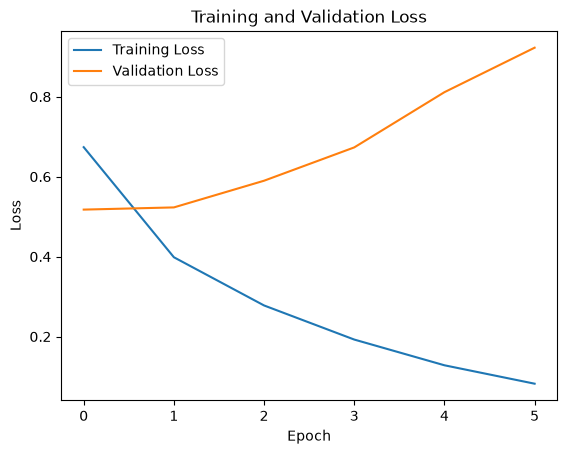

In [19]:
plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()

plt.show()

## 17. Model Evaluation on the Test Set

After training is completed, the final model is evaluated using the test dataset.

The test set has not been used during model training and therefore provides a more objective estimate of the model's ability to generalize to unseen data.

In [20]:
model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        outputs = model(X_batch)

        _, predictions = torch.max(
            outputs,
            1
        )

        all_predictions.extend(
            predictions.numpy()
        )

        all_targets.extend(
            y_batch.numpy()
        )

### 17.1 Classification Performance Metrics

Several metrics are used to evaluate the classifier.

- **Accuracy** measures the overall percentage of correct predictions.
- **Precision** measures how many predicted samples of a class are actually correct.
- **Recall** measures how many actual samples of a class are successfully identified.
- **F1-score** provides a balance between Precision and Recall.

These additional metrics are particularly important when the dataset contains class imbalance.

In [21]:
accuracy = accuracy_score(
    all_targets,
    all_predictions
)

initial_accuracy = accuracy

print("Accuracy:", accuracy)

print("\nClassification Report:")

print(
    classification_report(
        all_targets,
        all_predictions,
        target_names=label_encoder.classes_
    )
)

Accuracy: 0.7663934426229508

Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.84      0.85      1377
     neutral       0.56      0.60      0.58       465
    positive       0.67      0.70      0.69       354

    accuracy                           0.77      2196
   macro avg       0.70      0.71      0.71      2196
weighted avg       0.77      0.77      0.77      2196



### 17.2 Confusion Matrix

A confusion matrix is generated in order to analyze the types of classification errors made by the model.

The matrix shows how frequently tweets belonging to each actual sentiment class are classified into each predicted class.

In [22]:
cm = confusion_matrix(
    all_targets,
    all_predictions
)

print(cm)

[[1156  165   56]
 [ 122  278   65]
 [  54   51  249]]


### 17.3 Confusion Matrix Visualization

The confusion matrix is visualized to make the classification errors easier to interpret.

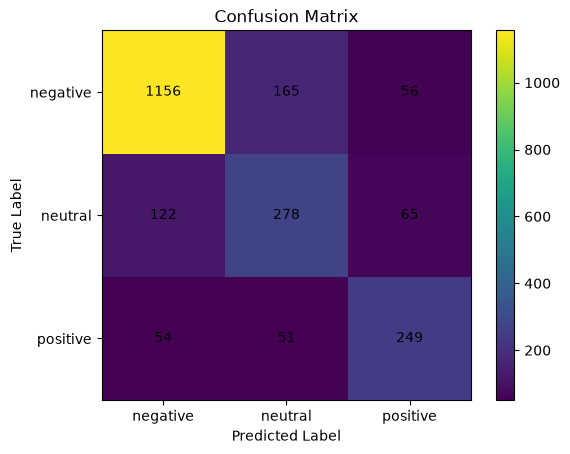

In [23]:
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

## 18. Interpretation of the Initial Results

The initial model achieved an overall accuracy of approximately **76.6%**.

The classification report showed that performance was strongest for the negative class, which achieved an F1-score of **0.85**. The neutral class achieved an F1-score of **0.58**, while the positive class achieved an F1-score of **0.69**.

The macro-average F1-score was **0.71**, indicating that performance was not equally strong across all three sentiment classes.

The training and validation loss curves revealed clear signs of overfitting. While the training loss continued to decrease, the validation loss increased after the first epoch.

This indicates that the model continued to fit the training data increasingly well, while its generalization performance deteriorated.

Therefore, the training procedure was revised so that the model parameters corresponding to the lowest validation loss could be stored and restored before the final test evaluation.

## 19. Model Revision: Restoring the Best Validation Model

Based on the initial results, the training procedure was revised.

The initial loss curves showed clear signs of overfitting. Although the training loss continued to decrease, the validation loss started to increase after the first few epochs.

The original Early Stopping implementation stopped the training process after the validation loss stopped improving. However, it did not restore the model parameters corresponding to the lowest validation loss.

Therefore, the revised training procedure:

1. monitors the validation loss after every epoch,
2. stores the model parameters whenever a new minimum validation loss is achieved,
3. applies Early Stopping when validation performance stops improving,
4. restores the parameters from the best validation epoch before the final test evaluation.

This ensures that the final model corresponds to the point of best validation performance rather than the final training epoch.

### 19.1 Reinitialize the Model

Before retraining, the neural network and optimizer are reinitialized.

This is necessary because the original model has already been trained. Reinitializing the model ensures that the revised experiment starts again from randomly initialized parameters and can therefore be fairly compared with the initial training procedure.

In [24]:
# Use the same initialization as the initial model
torch.manual_seed(SEED)

model = SentimentANN(
    input_size=input_size,
    num_classes=num_classes
)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

### 19.2 Revised Training with Early Stopping and Best Model Restoration

The model is retrained using the same architecture and hyperparameters as the initial experiment.

During training, the validation loss is monitored after each epoch.

Whenever a lower validation loss is observed, the current model parameters are stored. If the validation loss does not improve for five consecutive epochs, Early Stopping is triggered.

After training stops, the parameters corresponding to the lowest validation loss are restored.

In [25]:
import copy

num_epochs = 30
patience = 5

train_losses_revised = []
val_losses_revised = []

best_val_loss = float("inf")
best_model_state = None
best_epoch = 0

epochs_without_improvement = 0


for epoch in range(num_epochs):

    # -------------------------
    # Training phase
    # -------------------------

    model.train()

    total_train_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()


    avg_train_loss = total_train_loss / len(train_loader)


    # -------------------------
    # Validation phase
    # -------------------------

    model.eval()

    total_val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            total_val_loss += loss.item()


    avg_val_loss = total_val_loss / len(val_loader)


    # Store losses
    train_losses_revised.append(avg_train_loss)
    val_losses_revised.append(avg_val_loss)


    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"- Train Loss: {avg_train_loss:.4f} "
        f"- Validation Loss: {avg_val_loss:.4f}"
    )


    # -------------------------
    # Check validation improvement
    # -------------------------

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


        # -------------------------
        # Early Stopping
        # -------------------------

        if epochs_without_improvement >= patience:

            print("\nEarly stopping triggered.")

            break


# Restore the best model
model.load_state_dict(best_model_state)


print(
    f"\nBest Epoch: {best_epoch}"
)

print(
    f"Best Validation Loss: {best_val_loss:.4f}"
)

Epoch 1/30 - Train Loss: 0.6737 - Validation Loss: 0.5176
Epoch 2/30 - Train Loss: 0.3984 - Validation Loss: 0.5231
Epoch 3/30 - Train Loss: 0.2778 - Validation Loss: 0.5898
Epoch 4/30 - Train Loss: 0.1925 - Validation Loss: 0.6732
Epoch 5/30 - Train Loss: 0.1282 - Validation Loss: 0.8113
Epoch 6/30 - Train Loss: 0.0821 - Validation Loss: 0.9226

Early stopping triggered.

Best Epoch: 1
Best Validation Loss: 0.5176


## 20. Revised Training and Validation Loss

The training and validation loss curves of the revised training procedure are plotted below.

The validation loss is used to identify the epoch at which the model achieved its best generalization performance.

Although training may continue for several additional epochs because of the Early Stopping patience parameter, the final model parameters are restored from the epoch with the minimum validation loss.

An important observation is that the minimum validation loss was reached at Epoch 1.

This suggests that the network begins to overfit the training data very quickly. After the first epoch, the training loss continues to decrease, while the validation loss increases.

The relatively fast onset of overfitting may be related to the high-dimensional TF-IDF input and the capacity of the neural network.

Further regularization, a smaller network architecture or alternative hyperparameters could be explored in additional experiments. However, extensive hyperparameter tuning was not performed, since the objective of this exercise is to demonstrate the complete classification workflow rather than to fully optimize the model.

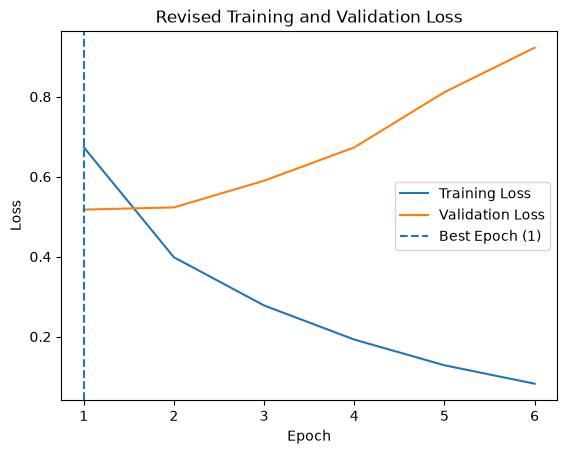

In [26]:
epochs = range(1, len(train_losses_revised) + 1)

plt.plot(
    epochs,
    train_losses_revised,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses_revised,
    label="Validation Loss"
)

plt.axvline(
    x=best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Revised Training and Validation Loss")

plt.legend()

plt.show()

## 21. Evaluation of the Revised Model

After restoring the parameters corresponding to the best validation epoch, the revised model is evaluated on the test set.

The test set remains independent from the training and model-selection process and is used only for the final evaluation.

In [27]:
model.eval()

revised_predictions = []
revised_targets = []


with torch.no_grad():

    for X_batch, y_batch in test_loader:

        outputs = model(X_batch)

        _, predictions = torch.max(
            outputs,
            1
        )

        revised_predictions.extend(
            predictions.numpy()
        )

        revised_targets.extend(
            y_batch.numpy()
        )

### 21.1 Revised Classification Performance

The revised model is evaluated using Accuracy, Precision, Recall and F1-score.

Because the sentiment classes are imbalanced, the class-specific scores and macro-average F1-score are particularly useful for evaluating whether the model performs consistently across the three sentiment categories.

In [28]:
revised_accuracy = accuracy_score(
    revised_targets,
    revised_predictions
)

print(
    f"Revised Model Accuracy: "
    f"{revised_accuracy:.4f}"
)


print(
    "\nRevised Classification Report:\n"
)


print(
    classification_report(
        revised_targets,
        revised_predictions,
        target_names=label_encoder.classes_
    )
)

Revised Model Accuracy: 0.8074

Revised Classification Report:

              precision    recall  f1-score   support

    negative       0.86      0.90      0.88      1377
     neutral       0.65      0.61      0.63       465
    positive       0.77      0.69      0.73       354

    accuracy                           0.81      2196
   macro avg       0.76      0.74      0.75      2196
weighted avg       0.80      0.81      0.80      2196



### 21.2 Revised Confusion Matrix

A confusion matrix is generated for the revised model in order to examine how the restored best-validation model classifies each sentiment category.

Particular attention is given to the neutral class, since the initial model frequently misclassified neutral tweets as negative.

In [29]:
revised_cm = confusion_matrix(
    revised_targets,
    revised_predictions
)

print(revised_cm)

[[1245  101   31]
 [ 139  282   44]
 [  56   52  246]]


### 21.3 Revised Confusion Matrix Visualization

The confusion matrix is visualized to provide a clearer representation of the classification performance of the revised model.

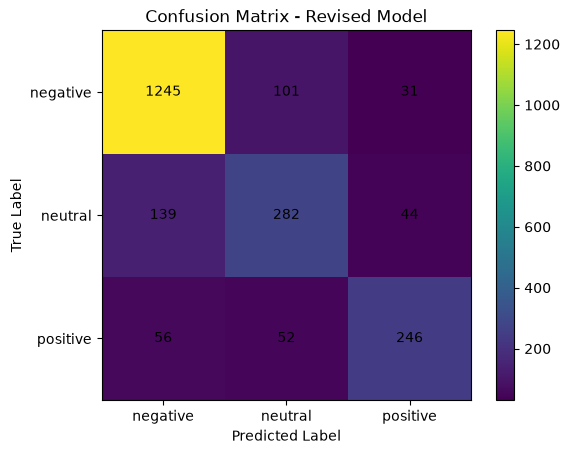

In [30]:
plt.imshow(revised_cm)

plt.title(
    "Confusion Matrix - Revised Model"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")


plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)


plt.colorbar()


for i in range(revised_cm.shape[0]):

    for j in range(revised_cm.shape[1]):

        plt.text(
            j,
            i,
            revised_cm[i, j],
            ha="center",
            va="center"
        )


plt.show()

### Reproducibility Note

For the final comparison, the kernel was restarted and the notebook was executed from the beginning.

This was necessary because, in an interactive notebook, repeatedly executing cells can modify the internal random state even when a fixed seed has been defined.

The seed was therefore reset before each model initialization to ensure that the initial and revised models started from identical random weights.

## 22. Initial vs Revised Model

The revised training procedure produced a clear improvement in overall model performance.

The initial model achieved an accuracy of approximately **76.6%**, while the revised model achieved approximately **80.7%**.

The class-specific F1-scores changed as follows:

- Negative F1-score increased from **0.85 to 0.88**
- Neutral F1-score increased from **0.58 to 0.63**
- Positive F1-score increased from **0.69 to 0.73**

The macro-average F1-score improved from **0.71 to 0.75**, while the weighted-average F1-score improved from **0.77 to 0.80**.

The best validation performance was achieved at **Epoch 1**, with a validation loss of **0.5176**.

Although training continued until Early Stopping was triggered, the revised procedure restored the model parameters corresponding to the best validation epoch.

Because the same random seed, architecture, dataset split and training hyperparameters were used in both experiments, the comparison between the initial and revised procedures is more reproducible and reliable.

In [31]:
print(
    f"Initial Model Accuracy: "
    f"{initial_accuracy:.4f}"
)

print(
    f"Revised Model Accuracy: "
    f"{revised_accuracy:.4f}"
)

print(
    f"Best Validation Epoch: "
    f"{best_epoch}"
)

print(
    f"Best Validation Loss: "
    f"{best_val_loss:.4f}"
)

Initial Model Accuracy: 0.7664
Revised Model Accuracy: 0.8074
Best Validation Epoch: 1
Best Validation Loss: 0.5176


## 23. Final Conclusions

In this exercise, a feed-forward Artificial Neural Network was developed to classify airline tweets into negative, neutral and positive sentiment categories.

The tweet text was preprocessed and transformed into numerical features using TF-IDF. Exploratory Data Analysis revealed a clear class imbalance, with negative tweets representing the majority of the dataset.

The initial ANN achieved an accuracy of approximately **76.6%** and a macro-average F1-score of **0.71**.

However, analysis of the training and validation loss curves revealed clear signs of overfitting. The validation loss reached its minimum at **Epoch 1** and subsequently increased, while the training loss continued to decrease.

Based on this observation, the training procedure was revised so that the model parameters corresponding to the lowest validation loss were stored and restored before final evaluation.

The best validation loss was **0.5176**, obtained at **Epoch 1**.

After restoring the model from this epoch, test accuracy increased to approximately **80.7%**, while the macro-average F1-score improved from **0.71 to 0.75**.

Performance improved across all three sentiment classes. In particular, the neutral class F1-score increased from **0.58 to 0.63**, while the negative class improved from **0.85 to 0.88** and the positive class from **0.69 to 0.73**.

The results demonstrate the importance of monitoring validation loss during neural network training and restoring the model parameters from the epoch with the best validation performance.

Possible future improvements could include:

- applying class weights to further address class imbalance,
- experimenting with different dropout rates or network architectures,
- tuning TF-IDF parameters,
- using alternative text representations such as Word2Vec or FastText.